---
authors:
  - name: Lukas Heumos
---


(chromatin-accessibility-dimensionality-reduction-clustering)=
# Dimensionality reduction and clustering

(chromatin-accessibility-dimensionality-reduction-clustering-key-takeaway-1)=
## Motivation

Unlike genes in scRNA-seq data, scATAC-seq data have no predefined features.
Peaks called on all cells miss regions that are only accessible in rare cell types, while peaks called per cluster require clusters in the first place.
We therefore count fragments in fixed 500 bp tiles across the genome, which cluster cells as well as peaks do {cite:p}`atacdr:luo2024benchmarking`, and call peaks per cell type in the [next chapter](peaks_motifs.ipynb).
We keep counts instead of binarizing them, since the number of fragments in a region carries information {cite:p}`atacdr:martens2024`, and SnapATAC2 counts the two insertions of a fragment only once if both fall into the same tile {cite:p}`atacdr:miao2024`.

In [1]:
import logging

import lamindb as ln
import scanpy as sc
import snapatac2 as snap

for name in ("kaleido", "choreographer"):
    logging.getLogger(name).setLevel(logging.WARNING)
sc.set_figure_params(dpi=80, facecolor="white", frameon=False)

ln.connect("theislab/sc-best-practices")

ln.track("x9Pv2jyr9s04")

→ connected lamindb: theislab/sc-best-practices


→ loaded Transform('x9Pv2jyr9s040000', key='dimensionality_reduction_clustering.ipynb'), started new Run('kEvPN62vBb8JKGqD') at 2026-09-29 15:27:38 UTC


→ notebook imports: lamindb-core==2.10.0 scanpy==1.12.4 snapatac2==2.10.0


We load the cells that passed [quality control](quality_control.ipynb), which already contain the tile matrix.

In [2]:
adata = ln.Artifact.get(
    key="chromatin_accessibility/pbmc10k_quality_control.h5ad"
).load()
adata

AnnData object with n_obs × n_vars = 9255 × 6062095
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse', 'doublet_probability', 'doublet_score'
    var: 'count', 'selected'
    uns: 'TSS_profile', 'doublet_rate', 'frac_overlap_TSS', 'frag_size_distr', 'library_tsse', 'reference_sequences', 'scrublet_sim_doublet_score'
    obsm: 'fragment_paired'
    layers: None (.X)

(chromatin-accessibility-dimensionality-reduction-clustering-key-takeaway-2)=
## Dimensionality reduction

Of the 6 million tiles, we selected the 250,000 most informative ones during quality control, close to the 200,000 features with which SnapATAC2 performed best in the benchmark {cite:p}`atacdr:luo2024benchmarking`.
SnapATAC2's spectral embedding computes the eigenvectors of the cosine similarity between cells without building the full similarity matrix, which makes it scale to millions of cells {cite:p}`atacdr:zhang2024snapatac2`.
It also separated cell types better than latent semantic indexing (LSI), whose components remain correlated with the number of fragments per cell {cite:p}`atacdr:luo2024benchmarking`.

In [3]:
snap.tl.spectral(adata)

## Clustering

We cluster the cells with the Leiden algorithm on a nearest neighbor graph of the spectral embedding and visualize them with UMAP.
Coloring by the number of fragments checks that the embedding is not driven by sequencing depth.

In [4]:
snap.pp.knn(adata)
snap.tl.leiden(adata)
snap.tl.umap(adata)

/home/lheumos/miniforge3/envs/chromatin-accessibility/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


... storing 'leiden' as categorical


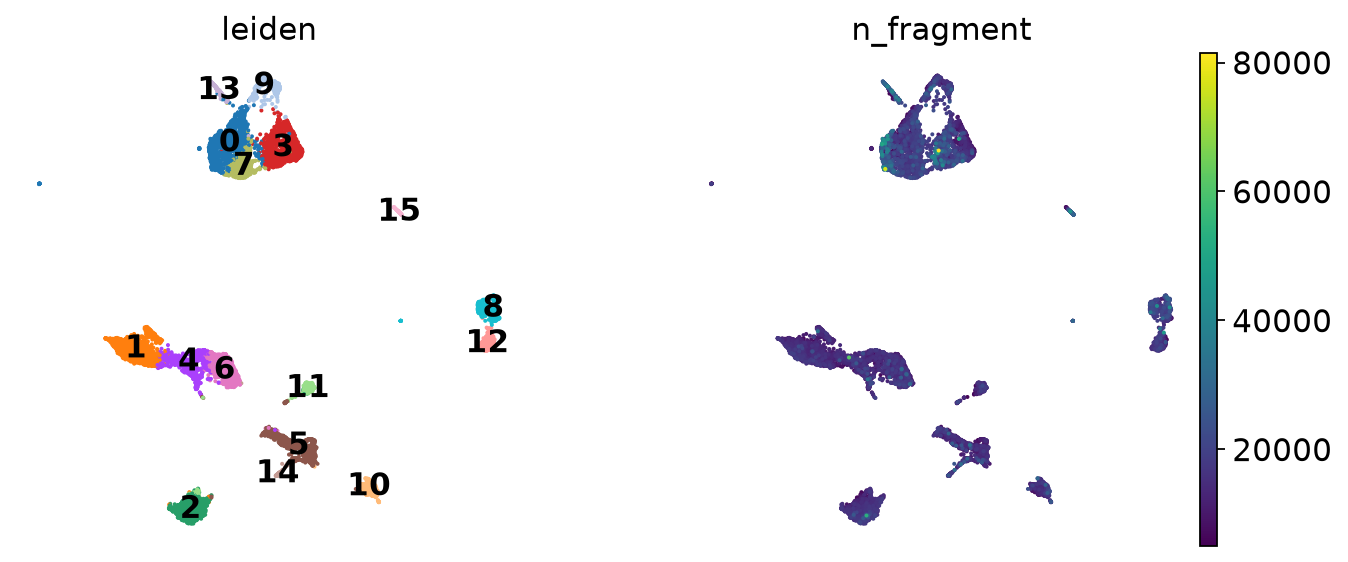

In [5]:
sc.pl.umap(adata, color=["leiden", "n_fragment"], legend_loc="on data")

(chromatin-accessibility-dimensionality-reduction-clustering-key-takeaway-3)=
## Cell type annotation

We annotate the clusters through the accessibility of marker genes.
SnapATAC2 estimates the activity of a gene from the insertions in its gene body and the 2 kb upstream of it, which approximated gene expression best among the tools in the benchmark {cite:p}`atacdr:luo2024benchmarking`.
Accessibility of a gene does not imply that it is transcribed, so a cell type should be supported by several markers.

In [6]:
annotation = ln.Artifact.get(
    key="chromatin_accessibility/gencode_v41_GRCh38.gff3.gz"
).cache()
gene_activity = snap.pp.make_gene_matrix(adata, annotation)
sc.pp.normalize_total(gene_activity)
sc.pp.log1p(gene_activity)

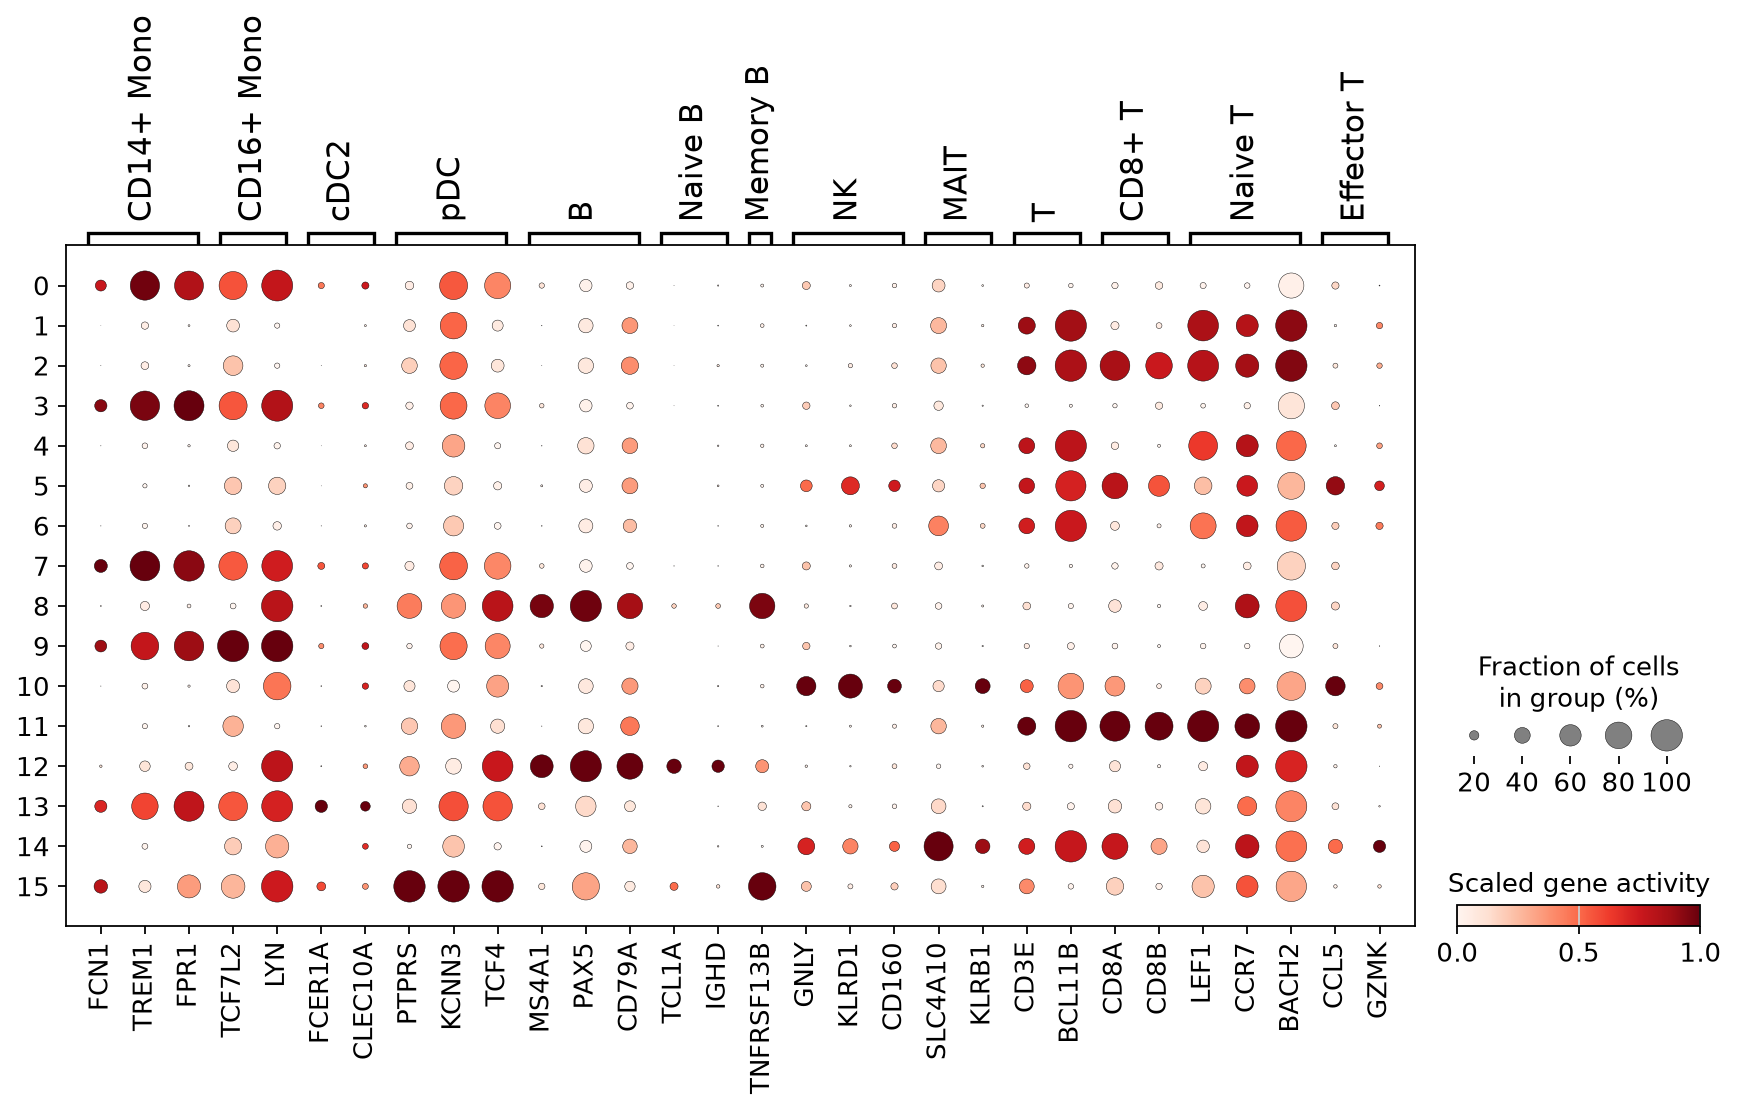

In [7]:
markers = {
    "CD14+ Mono": ["FCN1", "TREM1", "FPR1"],
    "CD16+ Mono": ["TCF7L2", "LYN"],
    "cDC2": ["FCER1A", "CLEC10A"],
    "pDC": ["PTPRS", "KCNN3", "TCF4"],
    "B": ["MS4A1", "PAX5", "CD79A"],
    "Naive B": ["TCL1A", "IGHD"],
    "Memory B": ["TNFRSF13B"],
    "NK": ["GNLY", "KLRD1", "CD160"],
    "MAIT": ["SLC4A10", "KLRB1"],
    "T": ["CD3E", "BCL11B"],
    "CD8+ T": ["CD8A", "CD8B"],
    "Naive T": ["LEF1", "CCR7", "BACH2"],
    "Effector T": ["CCL5", "GZMK"],
}
sc.pl.dotplot(
    gene_activity,
    markers,
    groupby="leiden",
    standard_scale="var",
    colorbar_title="Scaled gene activity",
)

Clusters 0, 3, 7 and 9 are monocytes, of which cluster 9 are CD16+ monocytes with the highest activity of TCF7L2, and cluster 13 are cDC2 with FCER1A and CLEC10A.
Cluster 15 are pDCs.
The B cells split into naive B cells with TCL1A and IGHD in cluster 12 and memory B cells with TNFRSF13B in cluster 8.
Cluster 10 are NK cells and cluster 14 MAIT cells.
All other clusters are T cells with CD3E and BCL11B.
Clusters 2 and 11 are naive CD8+ T cells, cluster 5 effector CD8+ T cells with CCL5 and GZMK, and clusters 1, 4 and 6 CD4+ T cells, which we keep together because these markers do not clearly separate naive from memory CD4+ T cells.

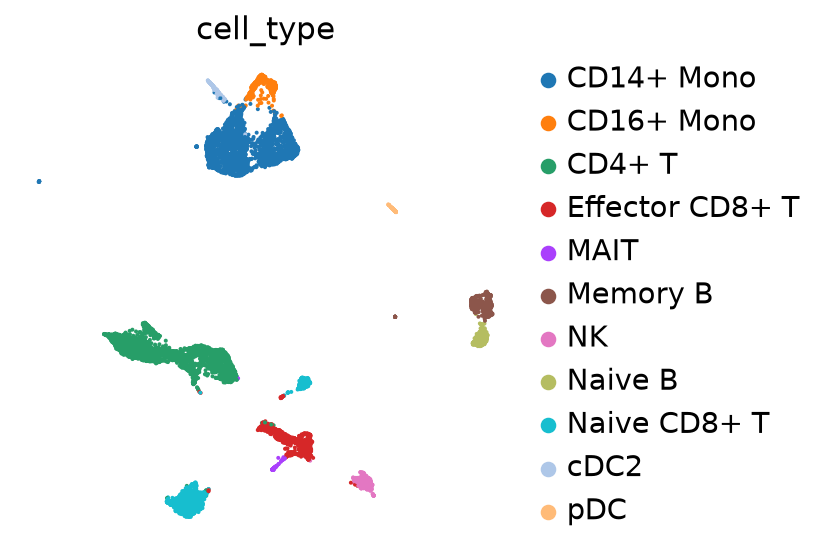

In [8]:
cell_types = {
    "0": "CD14+ Mono",
    "1": "CD4+ T",
    "2": "Naive CD8+ T",
    "3": "CD14+ Mono",
    "4": "CD4+ T",
    "5": "Effector CD8+ T",
    "6": "CD4+ T",
    "7": "CD14+ Mono",
    "8": "Memory B",
    "9": "CD16+ Mono",
    "10": "NK",
    "11": "Naive CD8+ T",
    "12": "Naive B",
    "13": "cDC2",
    "14": "MAIT",
    "15": "pDC",
}
adata.obs["cell_type"] = adata.obs["leiden"].map(cell_types).astype("category")
sc.pl.umap(adata, color="cell_type")

We store the annotated cells for [peak calling](peaks_motifs.ipynb).

In [9]:
ln.Artifact.from_anndata(
    adata,
    key="chromatin_accessibility/pbmc10k_clustered.h5ad",
    description="PBMC 10k multiome chromatin accessibility after clustering and annotation",
).save()

→ returning artifact with same hash: Artifact(uid='19dwbxDQ04HPT3VL0001', key='chromatin_accessibility/pbmc10k_clustered.h5ad', description='PBMC 10k multiome chromatin accessibility after clustering and annotation', suffix='.h5ad', kind='dataset', otype='AnnData', size=3269556941, hash='ZQsH6oBKvLqDqJDaJabYvF', n_files=None, n_observations=9255, extra_data=None, branch_id=1, created_on_id=1, space_id=1, storage_id=1, run_id=166, schema_id=None, created_by_id=2, created_at=2026-09-29 14:46:09 UTC, is_locked=False, version_tag=None, is_latest=True); to track this artifact as an input, use: ln.Artifact.get()


Artifact(uid='19dwbxDQ04HPT3VL0001', key='chromatin_accessibility/pbmc10k_clustered.h5ad', description='PBMC 10k multiome chromatin accessibility after clustering and annotation', suffix='.h5ad', kind='dataset', otype='AnnData', size=3269556941, hash='ZQsH6oBKvLqDqJDaJabYvF', n_files=None, n_observations=9255, extra_data=None, branch_id=1, created_on_id=1, space_id=1, storage_id=1, run_id=166, schema_id=None, created_by_id=2, created_at=2026-09-29 14:46:09 UTC, is_locked=False, version_tag=None, is_latest=True)

## Contributors

We gratefully acknowledge the contributions of:

### Authors

* Lukas Heumos